# Feature Engineering — DerMind Capstone Project
**Platform Kesehatan Digital Berbasis AI**

Notebook ini melakukan Feature Engineering pada semua dataset master DerMind.
Feature Engineering adalah proses membuat, mengubah, dan memilih fitur (kolom) baru
dari data mentah agar model AI/ML bisa belajar lebih baik dan akurat.

---

## Dataset yang Diproses
| # | Dataset | Baris | Tujuan |
|---|---------|-------|--------|
| 1 | `master_mental_health_clean.csv` | 52.940 | Klasifikasi kondisi mental (AI Chatbot) |
| 2 | `HAM10000_clean.csv` | 10.015 | Deteksi penyakit kulit klinis (AI Skin) |
| 3 | `master_sephora.csv` | 49.394 | Analisis sentimen produk skincare |
| 4 | `healthy_lifestyle_city_2021_cleaned.csv` | 44 | Analisis gaya hidup & kesehatan |

## Output
| File Output | Keterangan |
|---|---|
| `mental_health_features.csv` | Dataset mental health siap training |
| `ham10000_features.csv` | Dataset kulit klinis siap training |
| `sephora_features.csv` | Dataset skincare siap training |
| `lifestyle_features.csv` | Dataset lifestyle siap analisis |

## 1. Import Library & Load Data

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')

# ── DerMind color palette ──────────────────────────────────
G1 = '#059669'; G2 = '#10B981'; G3 = '#34D399'
BG = '#F8FAF9'; TX = '#1F2937'; R = '#EF4444'; Y = '#F59E0B'
PAL = [G1, '#0D9488', '#3B82F6', Y, R, '#8B5CF6', '#06B6D4', '#F97316', '#EC4899', G3]

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': '#F0FDF4',
    'axes.edgecolor': '#D1FAE5', 'axes.labelcolor': TX,
    'xtick.color': TX, 'ytick.color': TX,
    'text.color': TX, 'grid.color': '#D1FAE5',
    'figure.dpi': 120,
})

# Load semua dataset
df_mh   = pd.read_csv('master_mental_health_clean.csv')
df_ham  = pd.read_csv('HAM10000_clean.csv')
df_sep  = pd.read_csv('master_sephora.csv', low_memory=False)
df_life = pd.read_csv('healthy_lifestyle_city_2021_cleaned.csv')
df_life.columns = ['city','rank','sunshine_hours','water_cost','obesity_levels',
                   'life_expectancy','pollution_index','hours_worked',
                   'happiness','outdoor_activities','takeout_places','gym_cost']

print('Semua dataset berhasil dimuat!')
print(f'   Mental Health : {len(df_mh):,} baris | {df_mh.shape[1]} kolom')
print(f'   HAM10000      : {len(df_ham):,} baris | {df_ham.shape[1]} kolom')
print(f'   Sephora       : {len(df_sep):,} baris | {df_sep.shape[1]} kolom')
print(f'   Lifestyle     : {len(df_life):,} baris | {df_life.shape[1]} kolom')

Semua dataset berhasil dimuat!
   Mental Health : 52,940 baris | 6 kolom
   HAM10000      : 10,015 baris | 9 kolom
   Sephora       : 49,394 baris | 26 kolom
   Lifestyle     : 44 baris | 12 kolom


---
# BAGIAN 1 — Mental Health Feature Engineering
**Dataset:** `master_mental_health_clean.csv`  
**Tujuan:** Menyiapkan fitur untuk model klasifikasi kondisi mental health (AI Chatbot)

## 1.1 — Cek Data Awal

In [25]:
print('=== DATA AWAL MENTAL HEALTH ===')
print(f'Shape  : {df_mh.shape}')
print(f'Kolom  : {list(df_mh.columns)}')
print(f'Missing: {df_mh.isnull().sum().sum()}')
print()
print('Distribusi Label:')
print(df_mh['label'].value_counts())
df_mh.head(3)

=== DATA AWAL MENTAL HEALTH ===
Shape  : (52940, 6)
Kolom  : ['text', 'text_clean', 'label', 'word_count', 'char_count', 'source']
Missing: 0

Distribusi Label:
label
Normal                  16127
Depression              15468
Suicidal                10631
Anxiety                  4052
Bipolar                  2993
Stress                   2775
Personality disorder      894
Name: count, dtype: int64


,text,text_clean,label,word_count,char_count,source
0,oh my gosh,oh my gosh,Anxiety,3,10,combined
1,"trouble sleeping, confused mind, restless hear...","trouble sleeping, confused mind, restless hear...",Anxiety,10,64,combined
2,"All wrong, back off dear, forward doubt. Stay ...","all wrong, back off dear, forward doubt. stay ...",Anxiety,14,78,combined


## 1.2 — Feature Engineering: Fitur Numerik dari Teks

In [26]:
df_mh_fe = df_mh.copy()

# ── Fitur 1: avg_word_length ──────────────────────────────
# Rata-rata panjang kata → indikasi kompleksitas tulisan
df_mh_fe['avg_word_length'] = (
    df_mh_fe['char_count'] / df_mh_fe['word_count'].replace(0, 1)
).round(2)

# ── Fitur 2: is_short_text ────────────────────────────────
# Flag teks sangat pendek — Normal cenderung teks pendek
df_mh_fe['is_short_text'] = (df_mh_fe['word_count'] < 30).astype(int)

# ── Fitur 3: is_long_text ─────────────────────────────────
# Flag teks sangat panjang — Bipolar/Personality Disorder cenderung panjang
df_mh_fe['is_long_text'] = (df_mh_fe['word_count'] >= 100).astype(int)

# ── Fitur 4: text_length_category ────────────────────────
# Kategorisasi panjang teks
def categorize_length(wc):
    if wc < 30:   return 'short'
    elif wc < 100: return 'medium'
    else:          return 'long'

df_mh_fe['text_length_category'] = df_mh_fe['word_count'].apply(categorize_length)

# ── Fitur 5: source_encoded ──────────────────────────────
# Encode sumber data: combined=0, reddit=1
df_mh_fe['source_encoded'] = (df_mh_fe['source'] == 'reddit').astype(int)

print('Fitur numerik dari teks selesai dibuat!')
print(df_mh_fe[['word_count','avg_word_length','is_short_text','is_long_text',
                  'text_length_category','source_encoded']].head(5))

Fitur numerik dari teks selesai dibuat!
   word_count  avg_word_length  is_short_text  is_long_text  \
0           3             3.33              1             0   
1          10             6.40              1             0   
2          14             5.57              1             0   
3          11             5.55              1             0   
4          14             5.14              1             0   

  text_length_category  source_encoded  
0                short               0  
1                short               0  
2                short               0  
3                short               0  
4                short               0  


## 1.3 — Label Encoding (Target Variable)

In [27]:
# ── Fitur 6: label_encoded ───────────────────────────────
# Encode label kondisi mental → angka untuk model
label_mapping = {
    'Normal'               : 0,
    'Depression'           : 1,
    'Suicidal'             : 2,
    'Anxiety'              : 3,
    'Stress'               : 4,
    'Bipolar'              : 5,
    'Personality disorder' : 6,
}
df_mh_fe['label_encoded'] = df_mh_fe['label'].map(label_mapping)

print('Label encoding selesai!')
print('\nMapping Label → Angka:')
for label, code in label_mapping.items():
    count = (df_mh_fe['label'] == label).sum()
    print(f'  {code} = {label:<25} ({count:,} data)')

Label encoding selesai!

Mapping Label → Angka:
  0 = Normal                    (16,127 data)
  1 = Depression                (15,468 data)
  2 = Suicidal                  (10,631 data)
  3 = Anxiety                   (4,052 data)
  4 = Stress                    (2,775 data)
  5 = Bipolar                   (2,993 data)
  6 = Personality disorder      (894 data)


## 1.4 — TF-IDF Vectorization (Fitur Teks ke Angka)

In [28]:
# ── Fitur 7: TF-IDF ──────────────────────────────────────
# TF-IDF = Term Frequency-Inverse Document Frequency
# Mengubah teks → vektor angka yang merepresentasikan bobot kata
# max_features=5000 → ambil 5000 kata paling informatif

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),      # unigram + bigram (kata tunggal + pasangan kata)
    min_df=5,                # abaikan kata yang muncul di kurang dari 5 dokumen
    max_df=0.95,             # abaikan kata yang muncul di lebih dari 95% dokumen
    sublinear_tf=True,       # gunakan log(tf) agar tidak bias ke teks panjang
    stop_words='english',
)

# Fit dan transform kolom text_clean
tfidf_matrix = tfidf.fit_transform(df_mh_fe['text_clean'].fillna(''))

print('TF-IDF selesai!')
print(f'   Shape TF-IDF matrix : {tfidf_matrix.shape}')
print(f'   Jumlah fitur        : {tfidf_matrix.shape[1]:,} fitur kata')
print(f'   Total data          : {tfidf_matrix.shape[0]:,} dokumen')
print()
print('10 Kata dengan bobot TF-IDF tertinggi:')
feature_names = tfidf.get_feature_names_out()
# Rata-rata bobot TF-IDF per kata
mean_tfidf = np.array(tfidf_matrix.mean(axis=0)).flatten()
top10_idx = mean_tfidf.argsort()[::-1][:10]
for i, idx in enumerate(top10_idx, 1):
    print(f'  {i:2}. {feature_names[idx]:<25} (skor: {mean_tfidf[idx]:.4f})')

TF-IDF selesai!
   Shape TF-IDF matrix : (52940, 5000)
   Jumlah fitur        : 5,000 fitur kata
   Total data          : 52,940 dokumen

10 Kata dengan bobot TF-IDF tertinggi:
   1. just                      (skor: 0.0332)
   2. like                      (skor: 0.0292)
   3. want                      (skor: 0.0272)
   4. feel                      (skor: 0.0251)
   5. know                      (skor: 0.0218)
   6. life                      (skor: 0.0205)
   7. really                    (skor: 0.0183)
   8. time                      (skor: 0.0182)
   9. people                    (skor: 0.0177)
  10. don                       (skor: 0.0169)


## 1.5 — Visualisasi Hasil Feature Engineering Mental Health

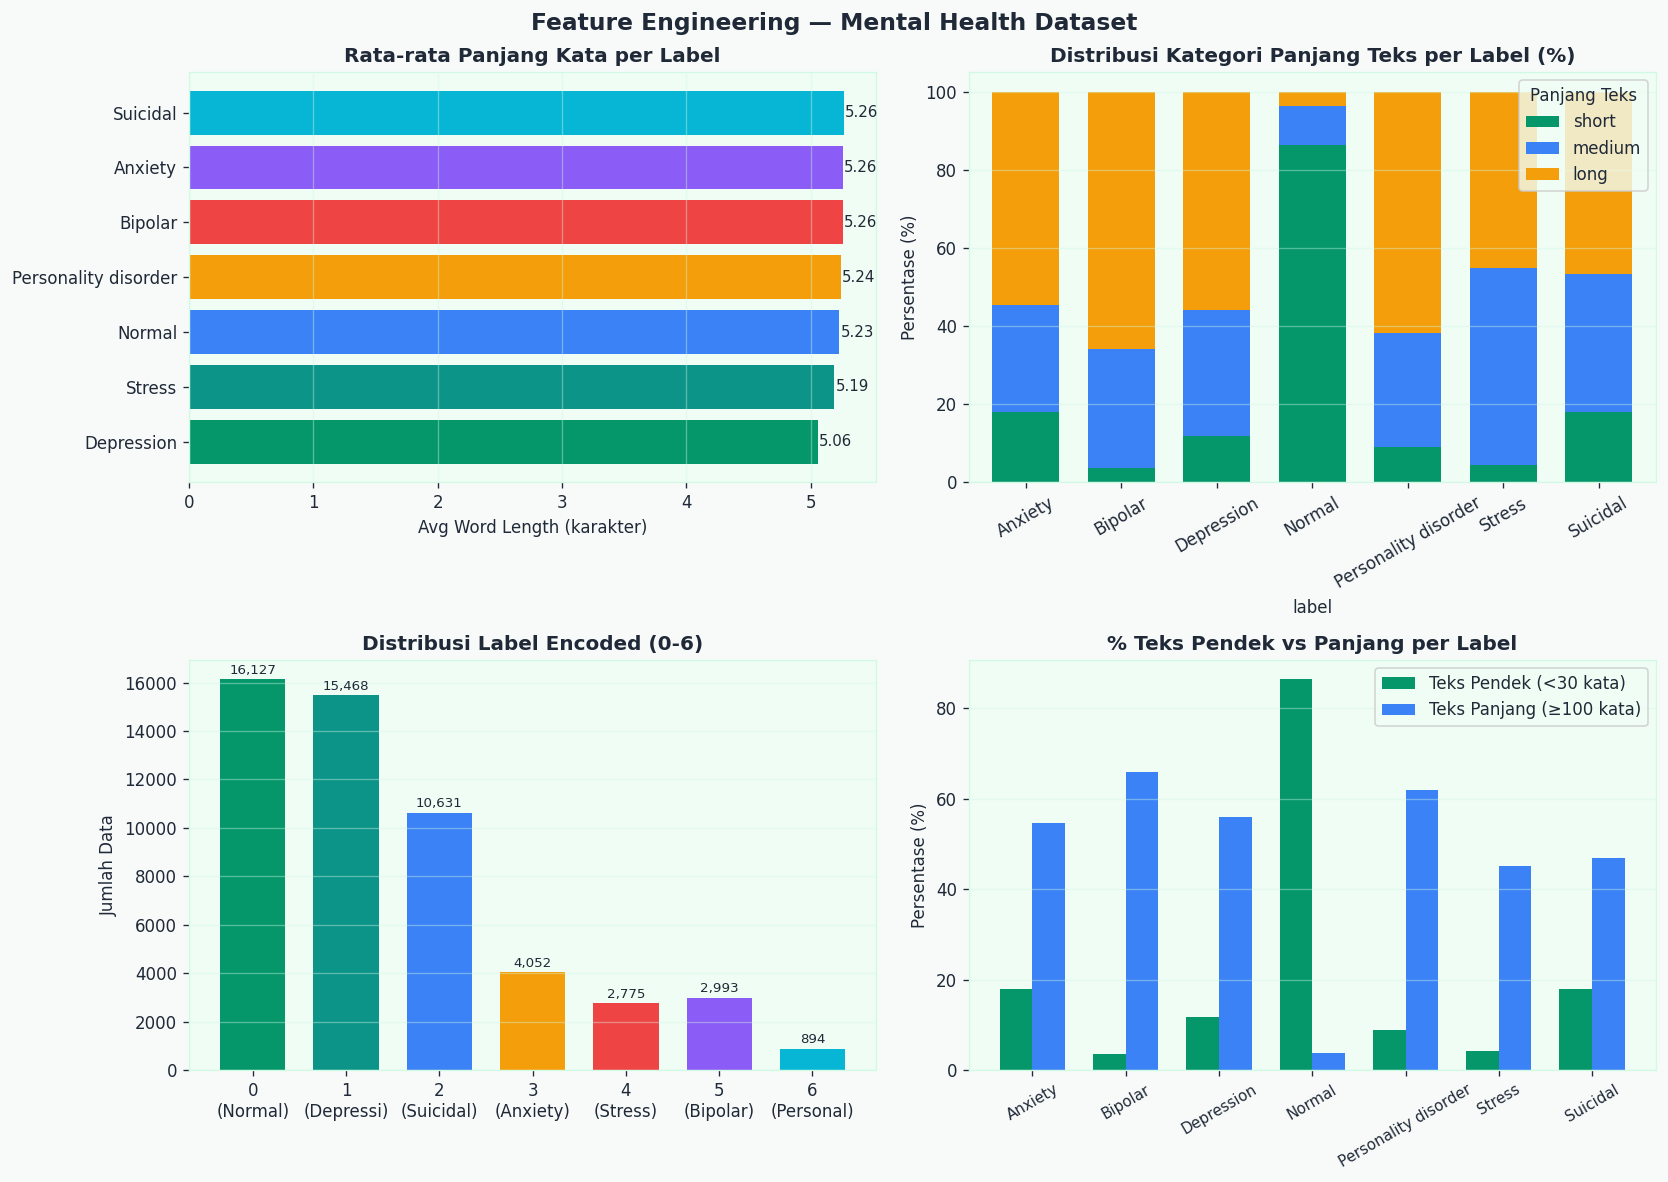

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Engineering — Mental Health Dataset', fontsize=14, fontweight='bold')

# 1. Distribusi avg_word_length per label
label_order = df_mh_fe.groupby('label')['avg_word_length'].mean().sort_values().index
avg_wl = df_mh_fe.groupby('label')['avg_word_length'].mean().reindex(label_order)
bars = axes[0,0].barh(avg_wl.index, avg_wl.values, color=PAL[:len(avg_wl)], edgecolor='none')
for bar, val in zip(bars, avg_wl.values):
    axes[0,0].text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
                   f'{val:.2f}', va='center', fontsize=9)
axes[0,0].set_title('Rata-rata Panjang Kata per Label', fontweight='bold')
axes[0,0].set_xlabel('Avg Word Length (karakter)')
axes[0,0].grid(axis='x', alpha=0.4)

# 2. Distribusi text_length_category per label
cat_cross = pd.crosstab(df_mh_fe['label'], df_mh_fe['text_length_category'], normalize='index') * 100
for col in ['short','medium','long']:
    if col not in cat_cross.columns: cat_cross[col] = 0
cat_cross[['short','medium','long']].plot(
    kind='bar', ax=axes[0,1], color=[G1, '#3B82F6', Y],
    stacked=True, edgecolor='none', width=0.7)
axes[0,1].set_title('Distribusi Kategori Panjang Teks per Label (%)', fontweight='bold')
axes[0,1].set_ylabel('Persentase (%)')
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].legend(title='Panjang Teks')
axes[0,1].grid(axis='y', alpha=0.4)

# 3. Label encoded distribution
vc_enc = df_mh_fe['label_encoded'].value_counts().sort_index()
label_names = {v:k for k,v in label_mapping.items()}
axes[1,0].bar([f'{i}\n({label_names[i][:8]})' for i in vc_enc.index],
               vc_enc.values, color=PAL[:7], edgecolor='none', width=0.7)
for i, val in enumerate(vc_enc.values):
    axes[1,0].text(i, val+100, f'{val:,}', ha='center', va='bottom', fontsize=8)
axes[1,0].set_title('Distribusi Label Encoded (0-6)', fontweight='bold')
axes[1,0].set_ylabel('Jumlah Data')
axes[1,0].grid(axis='y', alpha=0.4)

# 4. is_short_text vs is_long_text per label
short_pct = df_mh_fe.groupby('label')['is_short_text'].mean() * 100
long_pct  = df_mh_fe.groupby('label')['is_long_text'].mean() * 100
x = np.arange(len(short_pct))
w = 0.35
axes[1,1].bar(x - w/2, short_pct.values, w, label='Teks Pendek (<30 kata)', color=G1, edgecolor='none')
axes[1,1].bar(x + w/2, long_pct.values,  w, label='Teks Panjang (≥100 kata)', color='#3B82F6', edgecolor='none')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(short_pct.index, rotation=30, fontsize=9)
axes[1,1].set_title('% Teks Pendek vs Panjang per Label', fontweight='bold')
axes[1,1].set_ylabel('Persentase (%)')
axes[1,1].legend()
axes[1,1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('fe_mental_health.png', bbox_inches='tight', facecolor=BG)
plt.show()

## 1.6 — Simpan Hasil Feature Engineering Mental Health

In [30]:
# Kolom yang disimpan untuk training model
cols_to_save = [
    'text', 'text_clean',
    'label', 'label_encoded',
    'word_count', 'char_count', 'avg_word_length',
    'is_short_text', 'is_long_text', 'text_length_category',
    'source', 'source_encoded',
]
df_mh_out = df_mh_fe[cols_to_save]
df_mh_out.to_csv('mental_health_features.csv', index=False)

print('mental_health_features.csv tersimpan!')
print(f'   Shape  : {df_mh_out.shape}')
print(f'   Kolom  : {list(df_mh_out.columns)}')
print()
print('=== RINGKASAN FITUR MENTAL HEALTH ===')
print(df_mh_out.describe())

mental_health_features.csv tersimpan!
   Shape  : (52940, 12)
   Kolom  : ['text', 'text_clean', 'label', 'label_encoded', 'word_count', 'char_count', 'avg_word_length', 'is_short_text', 'is_long_text', 'text_length_category', 'source', 'source_encoded']

=== RINGKASAN FITUR MENTAL HEALTH ===
       label_encoded    word_count    char_count  avg_word_length  \
count   52940.000000  52940.000000  52940.000000     52940.000000   
mean        1.517095    118.914583    601.901096         5.187324   
std         1.530609    169.256484    867.955348        13.815052   
min         0.000000      1.000000     10.000000         2.000000   
25%         0.000000     17.000000     85.000000         4.770000   
50%         1.000000     67.000000    336.000000         5.020000   
75%         2.000000    157.000000    787.000000         5.330000   
max         6.000000   6300.000000  32759.000000      3162.750000   

       is_short_text  is_long_text  source_encoded  
count   52940.000000  52940.000

---
# BAGIAN 2 — HAM10000 Feature Engineering
**Dataset:** `HAM10000_clean.csv`  
**Tujuan:** Menyiapkan fitur demografis untuk model AI Skin Detection

## 2.1 — Cek Data Awal

In [31]:
print('=== DATA AWAL HAM10000 ===')
print(f'Shape  : {df_ham.shape}')
print(f'Kolom  : {list(df_ham.columns)}')
print(f'Missing: {df_ham.isnull().sum().sum()}')
print()
print('Distribusi Diagnosis (dx):')
print(df_ham['dx'].value_counts())
df_ham.head(3)

=== DATA AWAL HAM10000 ===
Shape  : (10015, 9)
Kolom  : ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'dx_full', 'is_duplicate_lesion']
Missing: 57

Distribusi Diagnosis (dx):
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


,lesion_id,image_id,dx,dx_type,age,sex,localization,dx_full,is_duplicate_lesion
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,Benign Keratosis,True
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,Benign Keratosis,True
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,Benign Keratosis,True


## 2.2 — Feature Engineering: Encoding Kategorikal

In [32]:
df_ham_fe = df_ham.copy()

# ── Fitur 1: dx_encoded (Target Variable) ────────────────
# Encode diagnosis penyakit → angka untuk model CNN
dx_mapping = {
    'nv'   : 0,  # Melanocytic Nevi (terbanyak, jinak)
    'mel'  : 1,  # Melanoma (berbahaya)
    'bkl'  : 2,  # Benign Keratosis (jinak)
    'bcc'  : 3,  # Basal Cell Carcinoma (berbahaya)
    'akiec': 4,  # Actinic Keratosis (pra-kanker)
    'vasc' : 5,  # Vascular Lesions (jinak)
    'df'   : 6,  # Dermatofibroma (jinak)
}
df_ham_fe['dx_encoded'] = df_ham_fe['dx'].map(dx_mapping)

# ── Fitur 2: sex_encoded ──────────────────────────────────
# male=0, female=1
df_ham_fe['sex_encoded'] = (df_ham_fe['sex'] == 'female').astype(int)

# ── Fitur 3: age_group + age_group_encoded ────────────────
# Kelompokkan usia menjadi 4 grup
df_ham_fe['age_group'] = pd.cut(
    df_ham_fe['age'], bins=[0, 20, 40, 60, 85],
    labels=['0-20', '21-40', '41-60', '61-85']
)
age_group_map = {'0-20': 0, '21-40': 1, '41-60': 2, '61-85': 3}
df_ham_fe['age_group_encoded'] = df_ham_fe['age_group'].map(age_group_map)

# ── Fitur 4: dx_type_encoded ─────────────────────────────
# Encode metode konfirmasi diagnosis (kualitas label)
dx_type_map = {
    'histo'     : 3,  # histopatologi = paling akurat
    'confocal'  : 2,  # confocal = akurat
    'follow_up' : 1,  # follow up
    'consensus' : 0,  # konsensus dokter = paling tidak pasti
}
df_ham_fe['dx_type_encoded'] = df_ham_fe['dx_type'].map(dx_type_map)

# ── Fitur 5: is_high_risk ─────────────────────────────────
# Flag penyakit berbahaya (Melanoma, Basal Cell Carcinoma, Actinic Keratosis)
high_risk = ['mel', 'bcc', 'akiec']
df_ham_fe['is_high_risk'] = df_ham_fe['dx'].isin(high_risk).astype(int)

# ── Fitur 6: is_duplicate_encoded ────────────────────────
df_ham_fe['is_duplicate_encoded'] = df_ham_fe['is_duplicate_lesion'].astype(int)

print('Encoding kategorikal selesai!')
print(df_ham_fe[['dx','dx_encoded','sex','sex_encoded','age','age_group',
                  'age_group_encoded','is_high_risk']].head(8))

Encoding kategorikal selesai!
    dx  dx_encoded   sex  sex_encoded   age age_group age_group_encoded  \
0  bkl           2  male            0  80.0     61-85                 3   
1  bkl           2  male            0  80.0     61-85                 3   
2  bkl           2  male            0  80.0     61-85                 3   
3  bkl           2  male            0  80.0     61-85                 3   
4  bkl           2  male            0  75.0     61-85                 3   
5  bkl           2  male            0  75.0     61-85                 3   
6  bkl           2  male            0  60.0     41-60                 2   
7  bkl           2  male            0  60.0     41-60                 2   

   is_high_risk  
0             0  
1             0  
2             0  
3             0  
4             0  
5             0  
6             0  
7             0  


## 2.3 — One-Hot Encoding Lokasi Tubuh

In [33]:
# ── Fitur 7: One-Hot Encoding lokasi tubuh ───────────────
# Karena lokasi tubuh nominal (tidak ada urutan), pakai One-Hot Encoding
# Hasilnya: kolom loc_back, loc_face, loc_trunk, dst

loc_dummies = pd.get_dummies(
    df_ham_fe['localization'],
    prefix='loc',
    dtype=int
)
df_ham_fe = pd.concat([df_ham_fe, loc_dummies], axis=1)

print('One-Hot Encoding lokasi tubuh selesai!')
print(f'   Kolom lokasi baru: {list(loc_dummies.columns)}')
print(f'   Contoh (5 baris pertama):')
print(df_ham_fe[list(loc_dummies.columns)].head(5))

One-Hot Encoding lokasi tubuh selesai!
   Kolom lokasi baru: ['loc_abdomen', 'loc_acral', 'loc_back', 'loc_chest', 'loc_ear', 'loc_face', 'loc_foot', 'loc_genital', 'loc_hand', 'loc_lower extremity', 'loc_neck', 'loc_scalp', 'loc_trunk', 'loc_unknown', 'loc_upper extremity']
   Contoh (5 baris pertama):
   loc_abdomen  loc_acral  loc_back  loc_chest  loc_ear  loc_face  loc_foot  \
0            0          0         0          0        0         0         0   
1            0          0         0          0        0         0         0   
2            0          0         0          0        0         0         0   
3            0          0         0          0        0         0         0   
4            0          0         0          0        1         0         0   

   loc_genital  loc_hand  loc_lower extremity  loc_neck  loc_scalp  loc_trunk  \
0            0         0                    0         0          1          0   
1            0         0                    0         0   

## 2.4 — Normalisasi Usia (Age Normalization)

In [34]:
# ── Fitur 8: age_normalized ──────────────────────────────
# Normalisasi usia ke skala 0-1 agar setara dengan fitur lain
# MinMaxScaler: (x - min) / (max - min)

scaler_age = MinMaxScaler()
df_ham_fe['age_normalized'] = scaler_age.fit_transform(
    df_ham_fe[['age']].fillna(df_ham_fe['age'].median())
)

print('Normalisasi usia selesai!')
print(f'   age range asli      : {df_ham_fe["age"].min():.0f} - {df_ham_fe["age"].max():.0f} tahun')
print(f'   age_normalized range: {df_ham_fe["age_normalized"].min():.3f} - {df_ham_fe["age_normalized"].max():.3f}')
print()
print('Contoh:')
print(df_ham_fe[['age','age_normalized','age_group','age_group_encoded']].head(8))

Normalisasi usia selesai!
   age range asli      : 0 - 85 tahun
   age_normalized range: 0.000 - 1.000

Contoh:
    age  age_normalized age_group age_group_encoded
0  80.0        0.941176     61-85                 3
1  80.0        0.941176     61-85                 3
2  80.0        0.941176     61-85                 3
3  80.0        0.941176     61-85                 3
4  75.0        0.882353     61-85                 3
5  75.0        0.882353     61-85                 3
6  60.0        0.705882     41-60                 2
7  60.0        0.705882     41-60                 2


## 2.5 — Visualisasi Hasil Feature Engineering HAM10000

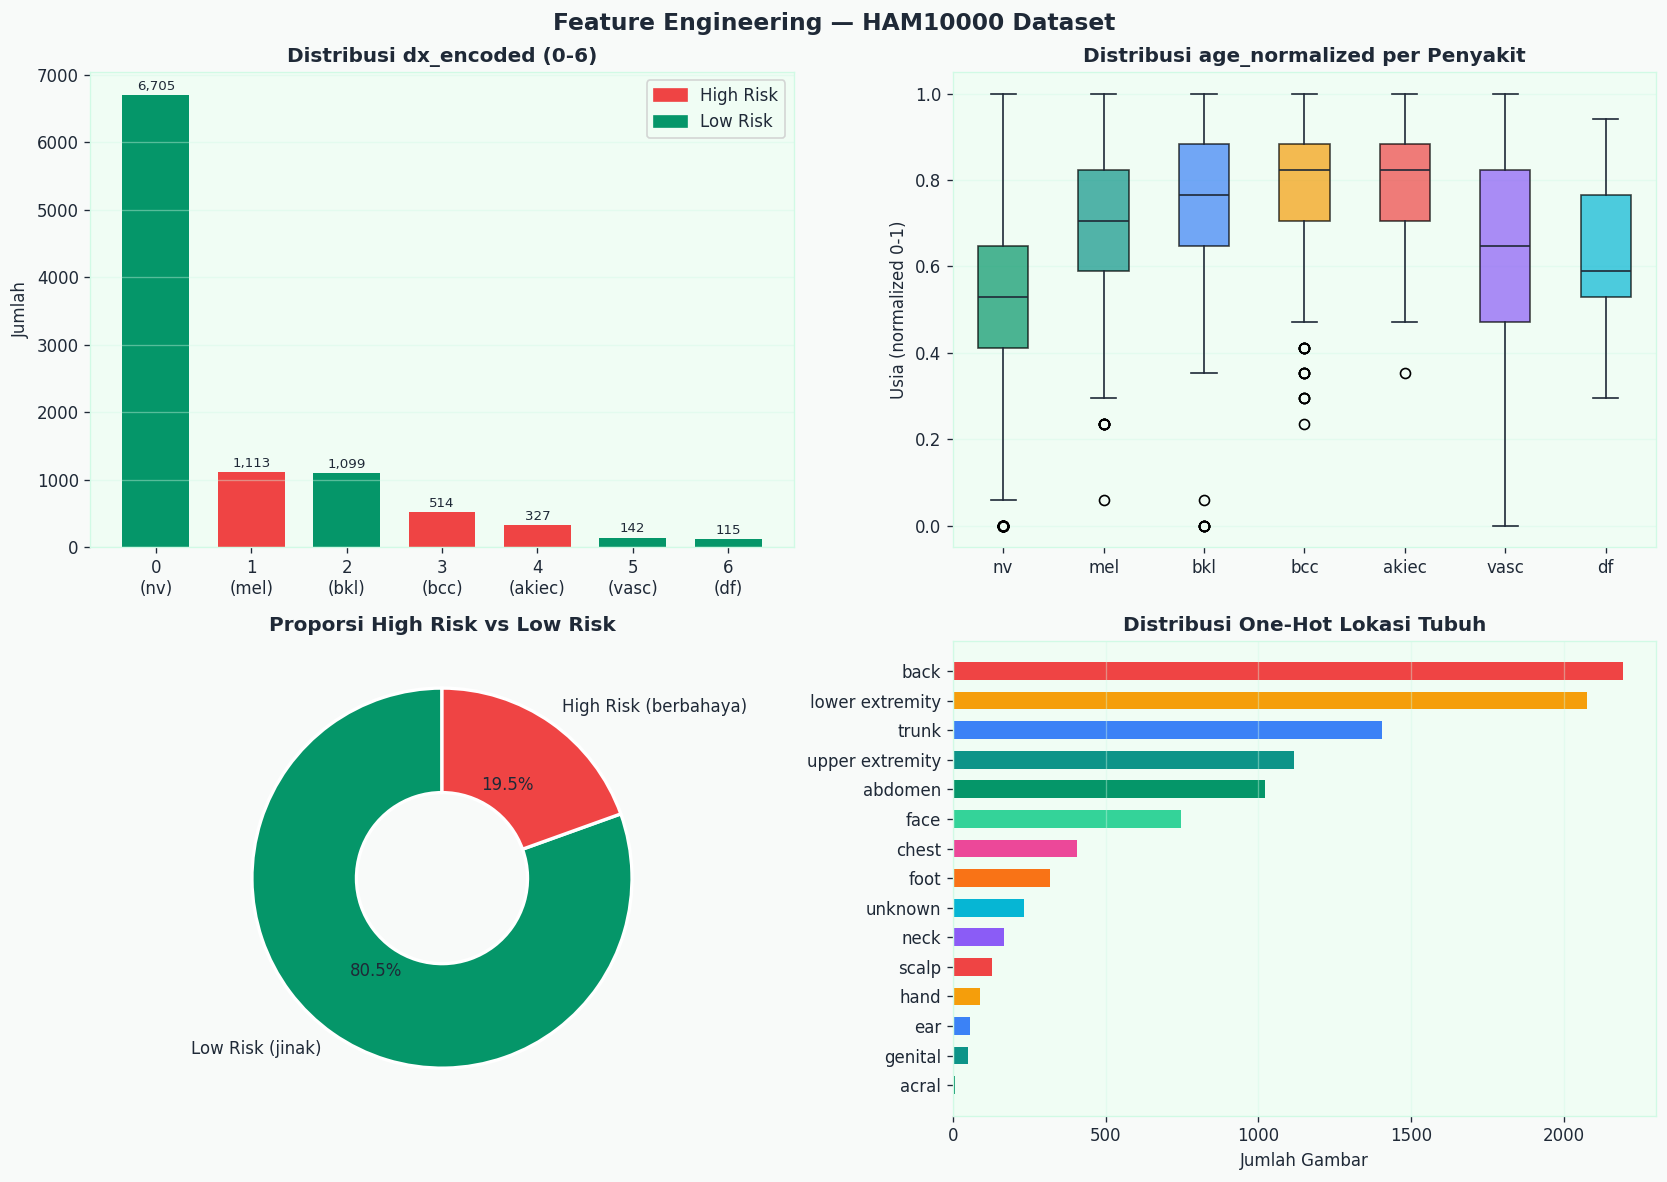

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Engineering — HAM10000 Dataset', fontsize=14, fontweight='bold')

dx_map_full = {'nv':'Melanocytic Nevi','mel':'Melanoma','bkl':'Benign Keratosis',
               'bcc':'Basal Cell Carcinoma','akiec':'Actinic Keratosis',
               'vasc':'Vascular Lesions','df':'Dermatofibroma'}

# 1. dx_encoded distribution
vc_dx = df_ham_fe['dx_encoded'].value_counts().sort_index()
colors_dx = [R if df_ham_fe[df_ham_fe['dx_encoded']==i]['is_high_risk'].values[0]==1
             else G1 for i in vc_dx.index]
axes[0,0].bar([f'{i}\n({list(dx_mapping.keys())[i]})' for i in vc_dx.index],
               vc_dx.values, color=colors_dx, edgecolor='none', width=0.7)
for i, val in enumerate(vc_dx.values):
    axes[0,0].text(i, val+30, f'{val:,}', ha='center', va='bottom', fontsize=8)
import matplotlib.patches as mpatches
axes[0,0].legend(handles=[
    mpatches.Patch(color=R, label='High Risk'),
    mpatches.Patch(color=G1, label='Low Risk')
])
axes[0,0].set_title('Distribusi dx_encoded (0-6)', fontweight='bold')
axes[0,0].set_ylabel('Jumlah')
axes[0,0].grid(axis='y', alpha=0.4)

# 2. age_normalized distribution per dx
dx_labels = [dx_map_full[dx] for dx in df_ham_fe['dx'].unique()]
data_age  = [df_ham_fe[df_ham_fe['dx']==dx]['age_normalized'].values
             for dx in dx_mapping.keys()]
bp = axes[0,1].boxplot(data_age, labels=[dx for dx in dx_mapping.keys()],
                        patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], PAL):
    patch.set_facecolor(color); patch.set_alpha(0.7)
for el in ['whiskers','caps','medians']:
    for line in bp[el]: line.set_color(TX)
axes[0,1].set_title('Distribusi age_normalized per Penyakit', fontweight='bold')
axes[0,1].set_ylabel('Usia (normalized 0-1)')
axes[0,1].grid(axis='y', alpha=0.4)

# 3. High risk vs Low risk
risk_vc = df_ham_fe['is_high_risk'].value_counts()
axes[1,0].pie(risk_vc.values, labels=['Low Risk (jinak)', 'High Risk (berbahaya)'],
              autopct='%1.1f%%', colors=[G1, R], startangle=90,
              wedgeprops={'edgecolor':'white','linewidth':2,'width':0.55})
axes[1,0].set_title('Proporsi High Risk vs Low Risk', fontweight='bold')

# 4. Top lokasi one-hot
loc_cols = [c for c in df_ham_fe.columns if c.startswith('loc_')]
loc_sum = df_ham_fe[loc_cols].sum().sort_values(ascending=True)
axes[1,1].barh(loc_sum.index.str.replace('loc_',''), loc_sum.values,
               color=PAL[:len(loc_sum)], edgecolor='none', height=0.6)
axes[1,1].set_title('Distribusi One-Hot Lokasi Tubuh', fontweight='bold')
axes[1,1].set_xlabel('Jumlah Gambar')
axes[1,1].grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('fe_ham10000.png', bbox_inches='tight', facecolor=BG)
plt.show()

## 2.6 — Simpan Hasil Feature Engineering HAM10000

In [36]:
# Kolom output untuk training model
base_cols = ['lesion_id','image_id','dx','dx_full','dx_encoded',
             'age','age_normalized','age_group','age_group_encoded',
             'sex','sex_encoded','localization',
             'dx_type','dx_type_encoded',
             'is_high_risk','is_duplicate_encoded']
loc_cols = [c for c in df_ham_fe.columns if c.startswith('loc_')]
df_ham_out = df_ham_fe[base_cols + loc_cols]
df_ham_out.to_csv('ham10000_features.csv', index=False)

print('ham10000_features.csv tersimpan!')
print(f'   Shape  : {df_ham_out.shape}')
print(f'   Kolom baru ditambahkan: dx_encoded, sex_encoded, age_group_encoded,')
print(f'                           dx_type_encoded, is_high_risk, age_normalized,')
print(f'                           + {len(loc_cols)} kolom one-hot lokasi')
print()
print(df_ham_out.head(3))

ham10000_features.csv tersimpan!
   Shape  : (10015, 31)
   Kolom baru ditambahkan: dx_encoded, sex_encoded, age_group_encoded,
                           dx_type_encoded, is_high_risk, age_normalized,
                           + 15 kolom one-hot lokasi

     lesion_id      image_id   dx           dx_full  dx_encoded   age  \
0  HAM_0000118  ISIC_0027419  bkl  Benign Keratosis           2  80.0   
1  HAM_0000118  ISIC_0025030  bkl  Benign Keratosis           2  80.0   
2  HAM_0002730  ISIC_0026769  bkl  Benign Keratosis           2  80.0   

   age_normalized age_group age_group_encoded   sex  ...  loc_face loc_foot  \
0        0.941176     61-85                 3  male  ...         0        0   
1        0.941176     61-85                 3  male  ...         0        0   
2        0.941176     61-85                 3  male  ...         0        0   

  loc_genital  loc_hand  loc_lower extremity  loc_neck  loc_scalp  loc_trunk  \
0           0         0                    0         0

---
# BAGIAN 3 — Sephora Feature Engineering
**Dataset:** `master_sephora_clean.csv`  
**Tujuan:** Menyiapkan fitur untuk analisis sentimen dan rekomendasi produk skincare

## 3.1 — Cek Data Awal

In [37]:
print('=== DATA AWAL SEPHORA ===')
print(f'Shape  : {df_sep.shape}')
print(f'Missing: {df_sep.isnull().sum().sum()}')
print()
print('Distribusi Sentimen:')
print(df_sep['sentiment'].value_counts())
print()
print('Distribusi Tipe Kulit:')
print(df_sep['skin_type'].value_counts())
df_sep.head(3)

=== DATA AWAL SEPHORA ===
Shape  : (49394, 26)
Missing: 40432

Distribusi Sentimen:
sentiment
Positive    39059
Negative     6600
Neutral      3735
Name: count, dtype: int64

Distribusi Tipe Kulit:
skin_type
combination    24866
dry             9155
normal          6645
oily            5118
Unknown         3610
Name: count, dtype: int64


,author_id,rating,is_recommended,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,...,price_usd,review_text_clean,sentiment,primary_category,secondary_category,highlights,limited_edition,new,online_only,sephora_exclusive
0,1945004256,5,1.0,2,2,0,2022-12-10,I absolutely L-O-V-E this oil. I have acne pro...,A must have!,lightMedium,...,65.0,I absolutely L-O-V-E this oil. I have acne pro...,Positive,Skincare,Moisturizers,NaN,0,0,0,0
1,5478482359,3,1.0,3,2,1,2021-12-17,I gave this 3 stars because it give me tiny li...,it keeps oily skin under control,mediumTan,...,65.0,I gave this 3 stars because it give me tiny li...,Neutral,Skincare,Moisturizers,NaN,0,0,0,0
2,29002209922,5,1.0,2,0,2,2021-06-07,Works well as soon as I wash my face and pat d...,Worth the money!,lightMedium,...,65.0,Works well as soon as I wash my face and pat d...,Positive,Skincare,Moisturizers,NaN,0,0,0,0


## 3.2 — Feature Engineering: Encoding & Fitur Baru

In [38]:
df_sep_fe = df_sep.copy()

# ── Fitur 1: sentiment_encoded ───────────────────────────
# Positive=2, Neutral=1, Negative=0
sentiment_map = {'Positive': 2, 'Neutral': 1, 'Negative': 0}
df_sep_fe['sentiment_encoded'] = df_sep_fe['sentiment'].map(sentiment_map)

# ── Fitur 2: skin_type_encoded ───────────────────────────
skin_map = {'combination': 0, 'oily': 1, 'dry': 2, 'normal': 3, 'Unknown': -1}
df_sep_fe['skin_type_encoded'] = df_sep_fe['skin_type'].map(skin_map)

# ── Fitur 3: price_category ──────────────────────────────
# Kategorisasi harga produk: Budget / Mid-range / Premium / Luxury
def categorize_price(price):
    if price <= 25:   return 'Budget'
    elif price <= 60: return 'Mid-range'
    elif price <= 150: return 'Premium'
    else:              return 'Luxury'

df_sep_fe['price_category'] = df_sep_fe['price_usd'].apply(categorize_price)
price_cat_map = {'Budget': 0, 'Mid-range': 1, 'Premium': 2, 'Luxury': 3}
df_sep_fe['price_category_encoded'] = df_sep_fe['price_category'].map(price_cat_map)

# ── Fitur 4: helpful_ratio ───────────────────────────────
# Rasio feedback positif — seberapa membantu ulasan ini
# +1 di denominator untuk hindari division by zero
df_sep_fe['helpful_ratio'] = (
    df_sep_fe['total_pos_feedback_count'] /
    (df_sep_fe['total_feedback_count'] + 1)
).round(3)

# ── Fitur 5: review_length ───────────────────────────────
# Panjang teks ulasan dalam karakter
df_sep_fe['review_length'] = df_sep_fe['review_text'].fillna('').apply(len)

# ── Fitur 6: review_word_count ───────────────────────────
df_sep_fe['review_word_count'] = (
    df_sep_fe['review_text'].fillna('').str.split().apply(len)
)

# ── Fitur 7: has_title ───────────────────────────────────
# Flag apakah ulasan punya judul (bukan 'No Title')
df_sep_fe['has_title'] = (df_sep_fe['review_title'] != 'No Title').astype(int)

# ── Fitur 8: category_encoded ────────────────────────────
# Label encoding kategori produk
le_cat = LabelEncoder()
df_sep_fe['category_encoded'] = le_cat.fit_transform(df_sep_fe['secondary_category'])

# ── Fitur 9: brand_encoded ───────────────────────────────
# Label encoding brand
le_brand = LabelEncoder()
df_sep_fe['brand_encoded'] = le_brand.fit_transform(df_sep_fe['brand_name'])

# ── Fitur 10: price_normalized ───────────────────────────
scaler_price = MinMaxScaler()
df_sep_fe['price_normalized'] = scaler_price.fit_transform(df_sep_fe[['price_usd']]).round(3)

print('Feature Engineering Sephora selesai!')
print(df_sep_fe[['rating','sentiment','sentiment_encoded','skin_type','skin_type_encoded',
                   'price_usd','price_category','helpful_ratio','review_word_count']].head(5))

Feature Engineering Sephora selesai!
   rating sentiment  sentiment_encoded    skin_type  skin_type_encoded  \
0       5  Positive                  2  combination                  0   
1       3   Neutral                  1         oily                  1   
2       5  Positive                  2          dry                  2   
3       5  Positive                  2  combination                  0   
4       5  Positive                  2  combination                  0   

   price_usd price_category  helpful_ratio  review_word_count  
0       65.0        Premium          0.000                168  
1       65.0        Premium          0.250                 60  
2       65.0        Premium          0.667                 16  
3       65.0        Premium          0.667                 10  
4       65.0        Premium          0.929                182  


## 3.3 — One-Hot Encoding Tipe Kulit

In [39]:
# ── Fitur 11: One-Hot Encoding skin_type ─────────────────
# Untuk model yang tidak bisa pakai ordinal encoding
skin_dummies = pd.get_dummies(
    df_sep_fe['skin_type'],
    prefix='skin',
    dtype=int
)
df_sep_fe = pd.concat([df_sep_fe, skin_dummies], axis=1)

print('One-Hot Encoding skin_type selesai!')
print(f'   Kolom baru: {list(skin_dummies.columns)}')
print(df_sep_fe[list(skin_dummies.columns)].head(5))

One-Hot Encoding skin_type selesai!
   Kolom baru: ['skin_Unknown', 'skin_combination', 'skin_dry', 'skin_normal', 'skin_oily']
   skin_Unknown  skin_combination  skin_dry  skin_normal  skin_oily
0             0                 1         0            0          0
1             0                 0         0            0          1
2             0                 0         1            0          0
3             0                 1         0            0          0
4             0                 1         0            0          0


## 3.4 — Visualisasi Hasil Feature Engineering Sephora

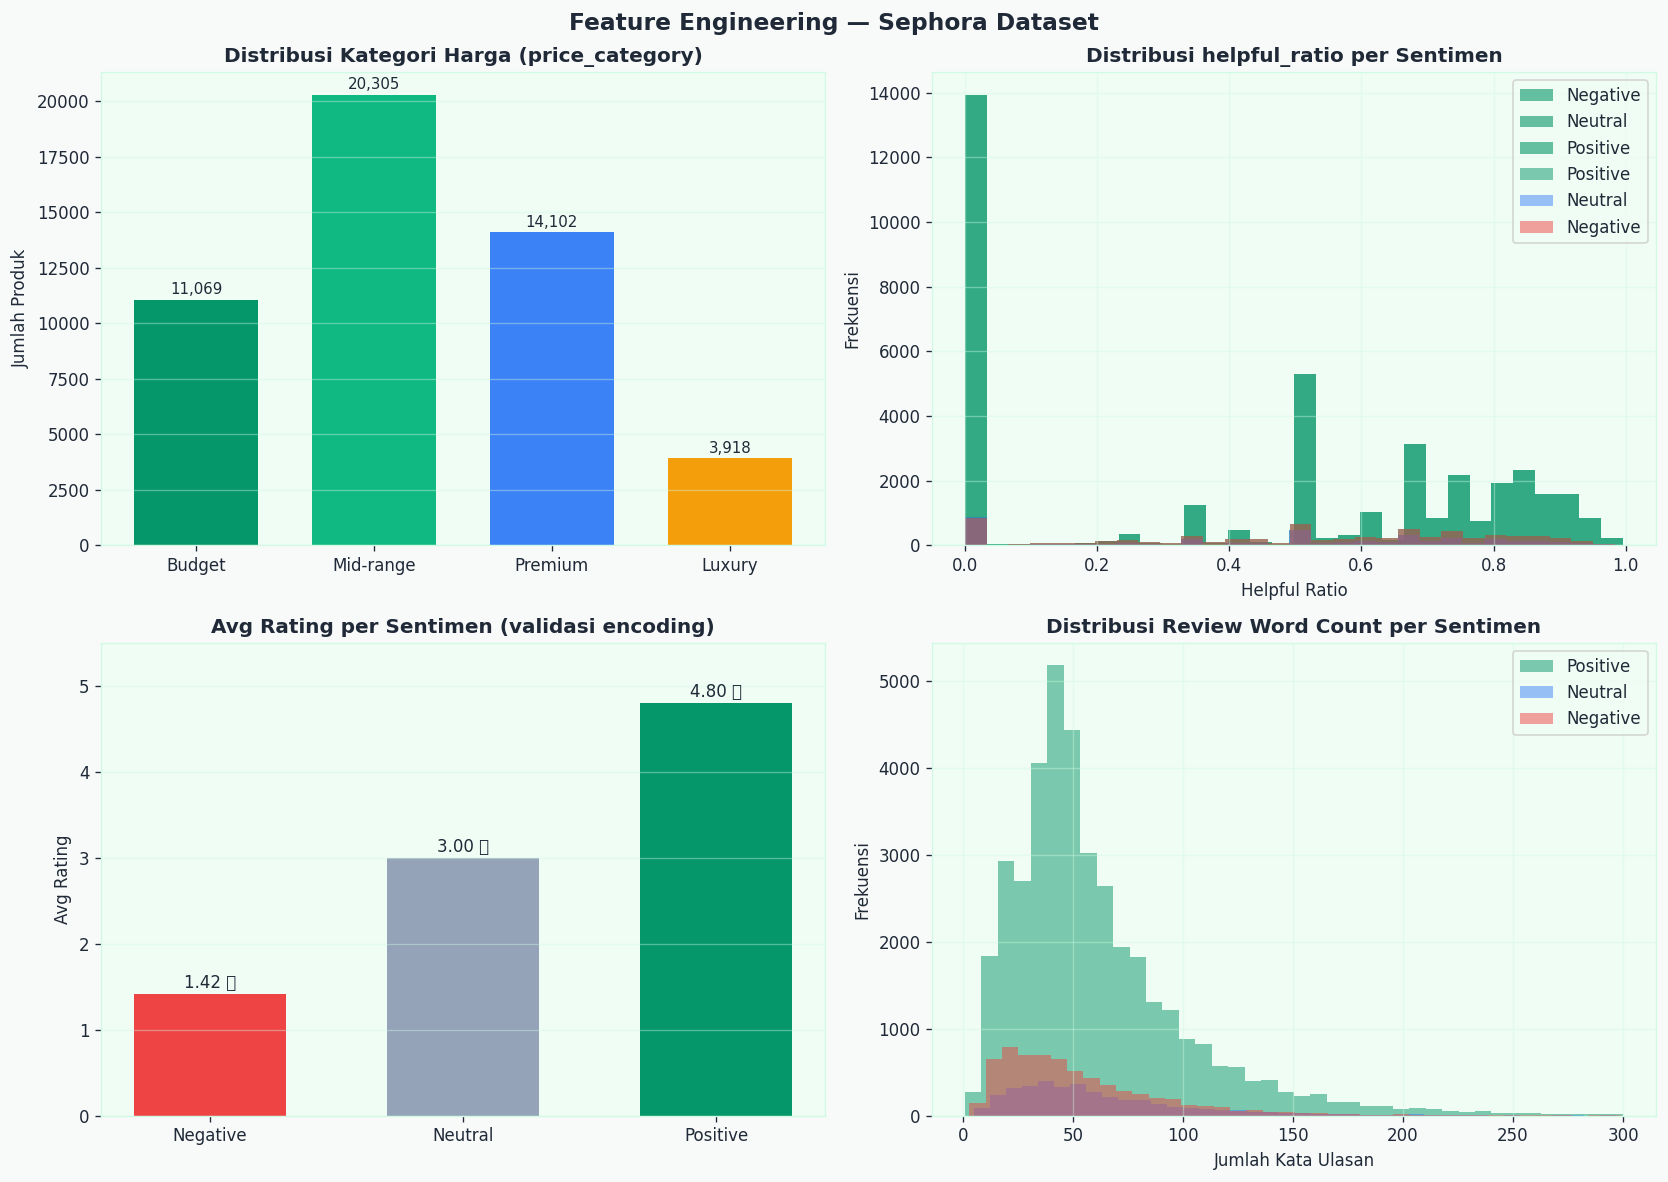

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Engineering — Sephora Dataset', fontsize=14, fontweight='bold')

# 1. Distribusi price_category
pc_vc = df_sep_fe['price_category'].value_counts().reindex(['Budget','Mid-range','Premium','Luxury'])
bars = axes[0,0].bar(pc_vc.index, pc_vc.values, color=[G1,G2,'#3B82F6',Y], edgecolor='none', width=0.7)
for bar, val in zip(bars, pc_vc.values):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                   f'{val:,}', ha='center', va='bottom', fontsize=9)
axes[0,0].set_title('Distribusi Kategori Harga (price_category)', fontweight='bold')
axes[0,0].set_ylabel('Jumlah Produk')
axes[0,0].grid(axis='y', alpha=0.4)

# 2. helpful_ratio per sentiment
df_sep_fe.groupby('sentiment')['helpful_ratio'].plot(
    kind='hist', ax=axes[0,1], bins=30, alpha=0.6,
    color=[G1,'#3B82F6',R][0]
)
for sent, color in zip(['Positive','Neutral','Negative'], [G1,'#3B82F6',R]):
    sub = df_sep_fe[df_sep_fe['sentiment']==sent]['helpful_ratio']
    axes[0,1].hist(sub, bins=30, alpha=0.5, label=sent, color=color, edgecolor='none')
axes[0,1].set_title('Distribusi helpful_ratio per Sentimen', fontweight='bold')
axes[0,1].set_xlabel('Helpful Ratio')
axes[0,1].set_ylabel('Frekuensi')
axes[0,1].legend()
axes[0,1].grid(alpha=0.4)

# 3. sentiment_encoded vs avg rating
avg_by_sent = df_sep_fe.groupby('sentiment')['rating'].mean().reindex(['Negative','Neutral','Positive'])
axes[1,0].bar(avg_by_sent.index, avg_by_sent.values, color=[R,'#94A3B8',G1], edgecolor='none', width=0.6)
for i, val in enumerate(avg_by_sent.values):
    axes[1,0].text(i, val+0.02, f'{val:.2f} ⭐', ha='center', va='bottom', fontsize=10)
axes[1,0].set_title('Avg Rating per Sentimen (validasi encoding)', fontweight='bold')
axes[1,0].set_ylabel('Avg Rating')
axes[1,0].set_ylim(0, 5.5)
axes[1,0].grid(axis='y', alpha=0.4)

# 4. review_word_count per sentiment
df_cap = df_sep_fe[df_sep_fe['review_word_count'] <= 300]
for sent, color in zip(['Positive','Neutral','Negative'], [G1,'#3B82F6',R]):
    sub = df_cap[df_cap['sentiment']==sent]['review_word_count']
    axes[1,1].hist(sub, bins=40, alpha=0.5, label=sent, color=color, edgecolor='none')
axes[1,1].set_title('Distribusi Review Word Count per Sentimen', fontweight='bold')
axes[1,1].set_xlabel('Jumlah Kata Ulasan')
axes[1,1].set_ylabel('Frekuensi')
axes[1,1].legend()
axes[1,1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig('fe_sephora.png', bbox_inches='tight', facecolor=BG)
plt.show()

## 3.5 — Simpan Hasil Feature Engineering Sephora

In [41]:
skin_cols = [c for c in df_sep_fe.columns if c.startswith('skin_')]
cols_sep_out = [
    'author_id','product_id','product_name','brand_name','brand_encoded',
    'secondary_category','category_encoded',
    'rating','sentiment','sentiment_encoded','is_recommended',
    'price_usd','price_normalized','price_category','price_category_encoded',
    'skin_type','skin_type_encoded',
    'helpful_ratio','review_length','review_word_count','has_title',
    'total_feedback_count','total_pos_feedback_count','total_neg_feedback_count',
    'limited_edition','new','online_only','sephora_exclusive',
    'review_text_clean',
] + skin_cols

df_sep_out = df_sep_fe[cols_sep_out]
df_sep_out.to_csv('sephora_features.csv', index=False)

print('sephora_features.csv tersimpan!')
print(f'   Shape  : {df_sep_out.shape}')
print(f'   Fitur baru: sentiment_encoded, skin_type_encoded, price_category,')
print(f'               price_normalized, helpful_ratio, review_length,')
print(f'               review_word_count, has_title, brand_encoded, category_encoded')
print(f'               + {len(skin_cols)} kolom one-hot skin_type')

sephora_features.csv tersimpan!
   Shape  : (49394, 37)
   Fitur baru: sentiment_encoded, skin_type_encoded, price_category,
               price_normalized, helpful_ratio, review_length,
               review_word_count, has_title, brand_encoded, category_encoded
               + 8 kolom one-hot skin_type


---
# BAGIAN 4 — Lifestyle Feature Engineering
**Dataset:** `healthy_lifestyle_city_2021_cleaned.csv`  
**Tujuan:** Normalisasi dan transformasi fitur untuk analisis korelasi gaya hidup

## 4.1 — Cleaning & Normalisasi

In [42]:
df_life_fe = df_life.copy()

# Convert kolom numerik yang masih string
num_cols_life = ['sunshine_hours','pollution_index','hours_worked']
for col in num_cols_life:
    df_life_fe[col] = pd.to_numeric(df_life_fe[col], errors='coerce')

# ── Fitur 1: Isi missing value dengan median ──────────────
for col in num_cols_life:
    missing = df_life_fe[col].isnull().sum()
    if missing > 0:
        median_val = df_life_fe[col].median()
        df_life_fe[col] = df_life_fe[col].fillna(median_val)
        print(f'  {col}: {missing} missing → diisi dengan median ({median_val:.1f})')

# ── Fitur 2: Normalisasi semua kolom numerik (0-1) ────────
numeric_features = ['sunshine_hours','water_cost','obesity_levels','life_expectancy',
                    'pollution_index','hours_worked','happiness',
                    'outdoor_activities','takeout_places','gym_cost']

scaler_life = MinMaxScaler()
normalized = scaler_life.fit_transform(df_life_fe[numeric_features])
for i, col in enumerate(numeric_features):
    df_life_fe[f'{col}_norm'] = normalized[:, i].round(3)

# ── Fitur 3: health_index ─────────────────────────────────
# Indeks kesehatan komposit:
# (+) happiness, life_expectancy, outdoor_activities, sunshine_hours
# (-) obesity_levels, pollution_index, hours_worked
df_life_fe['health_index'] = (
    df_life_fe['happiness_norm'] * 0.25 +
    df_life_fe['life_expectancy_norm'] * 0.20 +
    df_life_fe['outdoor_activities_norm'] * 0.15 +
    df_life_fe['sunshine_hours_norm'] * 0.10 +
    (1 - df_life_fe['obesity_levels_norm']) * 0.15 +
    (1 - df_life_fe['pollution_index_norm']) * 0.10 +
    (1 - df_life_fe['hours_worked_norm']) * 0.05
).round(3)

# ── Fitur 4: happiness_category ──────────────────────────
df_life_fe['happiness_category'] = pd.cut(
    df_life_fe['happiness'],
    bins=[0, 5.5, 6.5, 10],
    labels=['Low', 'Medium', 'High']
)

print('\n Feature Engineering Lifestyle selesai!')
print(df_life_fe[['city','rank','happiness','health_index','happiness_category']].head(10))

  sunshine_hours: 1 missing → diisi dengan median (2066.0)
  pollution_index: 1 missing → diisi dengan median (52.6)
  hours_worked: 11 missing → diisi dengan median (1686.0)

 Feature Engineering Lifestyle selesai!
         city  rank  happiness  health_index happiness_category
0   Amsterdam     1       7.44         0.739               High
1      Sydney     2       7.22         0.711               High
2      Vienna     3       7.29         0.666               High
3   Stockholm     4       7.35         0.670               High
4  Copenhagen     5       7.64         0.677               High
5    Helsinki     6       7.80         0.670               High
6     Fukuoka     7       5.87         0.633             Medium
7      Berlin     8       7.07         0.640               High
8   Barcelona     9       6.40         0.687             Medium
9   Vancouver    10       7.23         0.630               High


## 4.2 — Visualisasi Lifestyle Features

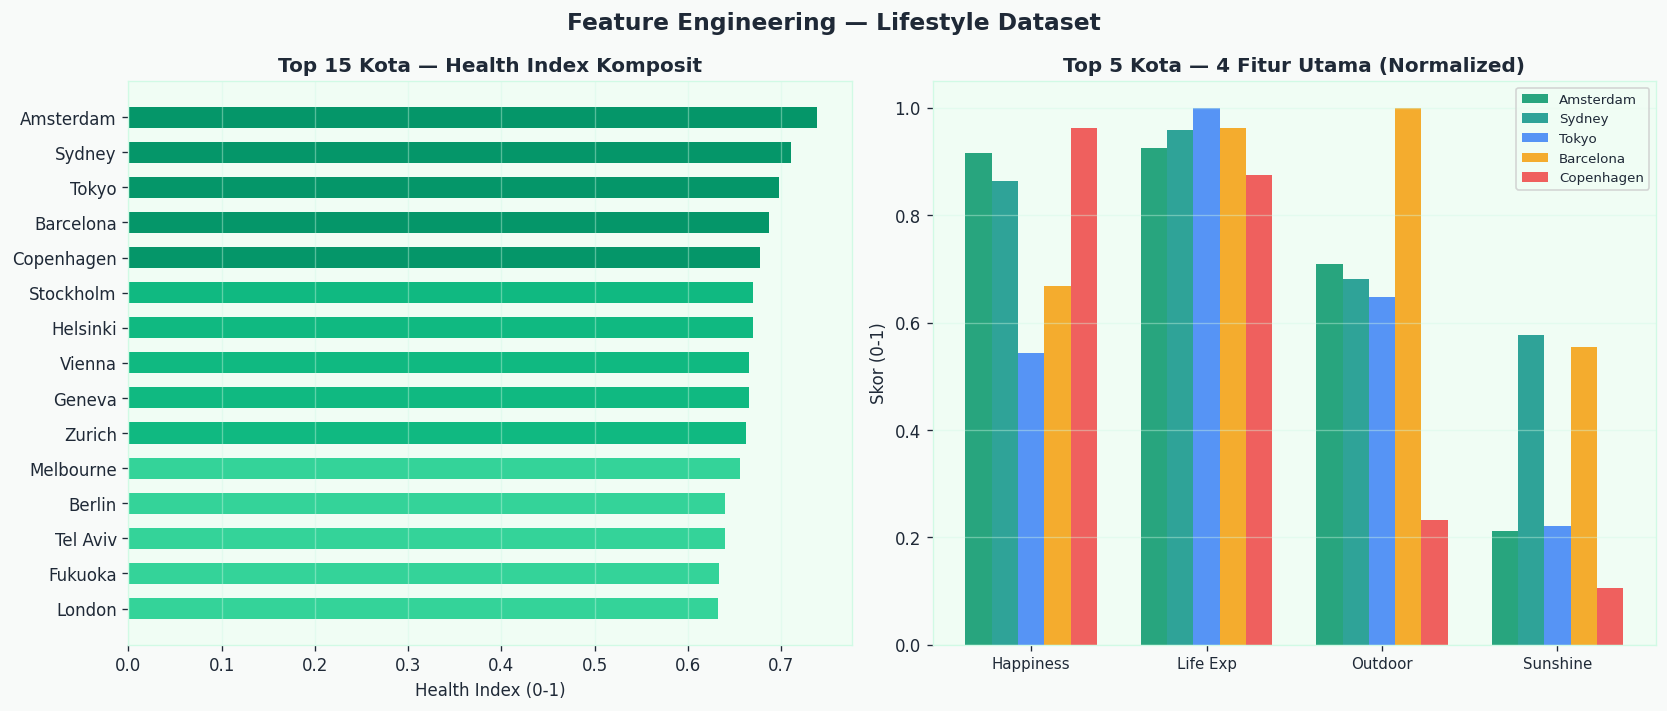

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Feature Engineering — Lifestyle Dataset', fontsize=14, fontweight='bold')

# 1. health_index ranking top 15
top15 = df_life_fe.nlargest(15, 'health_index')
bar_colors = [G1 if i < 5 else G2 if i < 10 else G3 for i in range(len(top15))]
axes[0].barh(top15['city'][::-1], top15['health_index'][::-1],
             color=bar_colors[::-1], edgecolor='none', height=0.6)
axes[0].set_title('Top 15 Kota — Health Index Komposit', fontweight='bold')
axes[0].set_xlabel('Health Index (0-1)')
axes[0].grid(axis='x', alpha=0.4)

# 2. Radar chart features normalized top 5 kota
top5 = df_life_fe.nlargest(5, 'health_index')
features_radar = ['happiness_norm','life_expectancy_norm','outdoor_activities_norm',
                  'sunshine_hours_norm']
x = np.arange(len(features_radar))
w = 0.15
for i, (_, row) in enumerate(top5.iterrows()):
    axes[1].bar(x + i*w, [row[f] for f in features_radar],
                w, label=row['city'], color=PAL[i], edgecolor='none', alpha=0.85)
axes[1].set_xticks(x + w*2)
axes[1].set_xticklabels(['Happiness','Life Exp','Outdoor','Sunshine'], fontsize=9)
axes[1].set_title('Top 5 Kota — 4 Fitur Utama (Normalized)', fontweight='bold')
axes[1].set_ylabel('Skor (0-1)')
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('fe_lifestyle.png', bbox_inches='tight', facecolor=BG)
plt.show()

## 4.3 — Simpan Hasil Feature Engineering Lifestyle

In [44]:
norm_cols = [f'{c}_norm' for c in numeric_features]
cols_life_out = ['city','rank'] + numeric_features + norm_cols + ['health_index','happiness_category']
df_life_out = df_life_fe[cols_life_out]
df_life_out.to_csv('lifestyle_features.csv', index=False)

print('lifestyle_features.csv tersimpan!')
print(f'   Shape  : {df_life_out.shape}')
print(f'   Fitur baru: {len(norm_cols)} kolom *_norm + health_index + happiness_category')

lifestyle_features.csv tersimpan!
   Shape  : (44, 24)
   Fitur baru: 10 kolom *_norm + health_index + happiness_category


---
# RINGKASAN FEATURE ENGINEERING


In [45]:
print('=' * 65)
print('FEATURE ENGINEERING SELESAI — RINGKASAN')
print('=' * 65)
print()

summary = [
    ('Mental Health', 'mental_health_features.csv',
     df_mh_out.shape, 'label_encoded, avg_word_length, is_short_text, is_long_text, text_length_category, source_encoded + TF-IDF matrix (5.000 fitur)'),
    ('HAM10000', 'ham10000_features.csv',
     df_ham_out.shape, 'dx_encoded, sex_encoded, age_normalized, age_group_encoded, dx_type_encoded, is_high_risk + 15 kolom one-hot lokasi'),
    ('Sephora', 'sephora_features.csv',
     df_sep_out.shape, 'sentiment_encoded, skin_type_encoded, price_category, price_normalized, helpful_ratio, review_word_count, has_title, brand_encoded + 5 kolom one-hot skin_type'),
    ('Lifestyle', 'lifestyle_features.csv',
     df_life_out.shape, '10 kolom *_norm (MinMaxScaler) + health_index + happiness_category'),
]

for name, fname, shape, features in summary:
    print(f' {name}')
    print(f'   Output : {fname}')
    print(f'   Shape  : {shape[0]:,} baris × {shape[1]} kolom')
    print(f'   Fitur  : {features}')
    print()

FEATURE ENGINEERING SELESAI — RINGKASAN

 Mental Health
   Output : mental_health_features.csv
   Shape  : 52,940 baris × 12 kolom
   Fitur  : label_encoded, avg_word_length, is_short_text, is_long_text, text_length_category, source_encoded + TF-IDF matrix (5.000 fitur)

 HAM10000
   Output : ham10000_features.csv
   Shape  : 10,015 baris × 31 kolom
   Fitur  : dx_encoded, sex_encoded, age_normalized, age_group_encoded, dx_type_encoded, is_high_risk + 15 kolom one-hot lokasi

 Sephora
   Output : sephora_features.csv
   Shape  : 49,394 baris × 37 kolom
   Fitur  : sentiment_encoded, skin_type_encoded, price_category, price_normalized, helpful_ratio, review_word_count, has_title, brand_encoded + 5 kolom one-hot skin_type

 Lifestyle
   Output : lifestyle_features.csv
   Shape  : 44 baris × 24 kolom
   Fitur  : 10 kolom *_norm (MinMaxScaler) + health_index + happiness_category

